<h2>Bank Customer Churn Analysis</h2>

In [61]:
import pandas as pd
import numpy as np
import seaborn as sns

<h3>1. Import & QA the data</h3>

In [62]:
# import data from both tabs in the Bank_Churn_Messy.xlsx
customers = pd.read_excel('Data/Bank_Churn_Messy.xlsx', sheet_name=0)
accounts = pd.read_excel('Data/Bank_Churn_Messy.xlsx', sheet_name=1)

In [63]:
customers.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1


In [64]:
accounts.head()

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
2,15647311,€83807.86,1,Yes,1,Yes,0
3,15619304,€159660.8,3,No,8,No,1
4,15701354,€0.0,2,No,1,No,0


In [65]:
df = accounts.merge(customers, on='CustomerId', how='left')

In [66]:
df.drop(columns=['Tenure_y'], inplace=True)

In [67]:
df = df.rename(columns= {'Tenure_x': 'Tenure'})

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10004 entries, 0 to 10003
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10004 non-null  int64  
 1   Balance          10004 non-null  str    
 2   NumOfProducts    10004 non-null  int64  
 3   HasCrCard        10004 non-null  str    
 4   Tenure           10004 non-null  int64  
 5   IsActiveMember   10004 non-null  str    
 6   Exited           10004 non-null  int64  
 7   Surname          10001 non-null  str    
 8   CreditScore      10004 non-null  int64  
 9   Geography        10004 non-null  str    
 10  Gender           10004 non-null  str    
 11  Age              10001 non-null  float64
 12  EstimatedSalary  10004 non-null  str    
dtypes: float64(1), int64(5), str(7)
memory usage: 1016.2 KB


In [69]:
df.describe()

,CustomerId,NumOfProducts,Tenure,Exited,CreditScore,Age
count,1.000400e+04,10004.000000,10004.000000,10004.000000,10004.000000,10001.000000
mean,1.569092e+07,1.529988,5.012195,0.203719,650.568073,38.919108
std,7.193218e+04,0.581635,2.891806,0.402782,96.665531,10.488725
min,1.556570e+07,1.000000,0.000000,0.000000,350.000000,18.000000
25%,1.562839e+07,1.000000,3.000000,0.000000,584.000000,32.000000
50%,1.569071e+07,1.000000,5.000000,0.000000,652.000000,37.000000
75%,1.575322e+07,2.000000,7.000000,0.000000,718.000000,44.000000
max,1.581569e+07,4.000000,10.000000,1.000000,850.000000,92.000000


In [70]:
df.drop_duplicates(inplace=True)

In [71]:
df.shape

(10000, 13)

In [72]:
df.head()

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,Surname,CreditScore,Geography,Gender,Age,EstimatedSalary
0,15634602,€0.0,1,Yes,2,Yes,1,Hargrave,619,FRA,Female,42.0,€101348.88
2,15647311,€83807.86,1,Yes,1,Yes,0,Hill,608,Spain,Female,41.0,€112542.58
3,15619304,€159660.8,3,No,8,No,1,Onio,502,French,Female,42.0,€113931.57
4,15701354,€0.0,2,No,1,No,0,Boni,699,FRA,Female,39.0,€93826.63
5,15737888,€125510.82,1,Yes,2,Yes,0,Mitchell,850,Spain,Female,43.0,€79084.1


<h3>2. Clean the data</h3>

In [73]:
df.dtypes

CustomerId           int64
Balance                str
NumOfProducts        int64
HasCrCard              str
Tenure               int64
IsActiveMember         str
Exited               int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                float64
EstimatedSalary        str
dtype: object

In [74]:
df[df.isna().any(axis=1)]

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,Surname,CreditScore,Geography,Gender,Age,EstimatedSalary
29,15728693,€141349.43,1,Yes,3,Yes,0,NaN,574,Germany,Female,NaN,-€999999
122,15580203,€120193.42,1,No,6,No,0,NaN,674,Spain,Male,NaN,-€999999
9390,15756954,€0.0,1,Yes,2,Yes,0,NaN,538,France,Female,NaN,-€999999


In [75]:
df['Balance'] = df['Balance'].str.replace('€','').astype(float)

In [76]:
df['EstimatedSalary'] = df['EstimatedSalary'].str.replace(
    '€', '').astype(float)

In [77]:
df['HasCrCard'] = np.where(df['HasCrCard'] == 'Yes', 1, 0)

In [78]:
df['IsActiveMember'] = np.where(df['IsActiveMember'] == 'Yes', 1, 0)

In [79]:
df['Surname'] = df['Surname'].fillna('MISSING')

In [80]:
df['Age'] = df['Age'].fillna(np.round(df['Age'].mean(),0))

In [81]:
df['Age'] = df['Age'].astype(int)

In [82]:
df[df.isna().any(axis=1)]

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,Surname,CreditScore,Geography,Gender,Age,EstimatedSalary


In [83]:
df.sample(10)

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,Surname,CreditScore,Geography,Gender,Age,EstimatedSalary
470,15749167,0.00,2,1,3,1,0,Fisk,753,FRA,Male,35,184843.77
9602,15797692,89939.62,1,0,7,0,0,Volkova,659,France,Female,33,136540.09
5667,15649616,124447.73,1,1,7,1,1,Otutodilichukwu,636,Spain,Male,60,141364.62
2941,15772798,0.00,2,1,5,1,0,Chikezie,711,Spain,Female,28,93959.96
7579,15656417,132077.48,2,0,1,0,0,Marsh,582,French,Female,39,192255.15
6600,15739578,128663.90,1,0,6,0,1,Chiazagomekpere,850,French,Male,49,65769.30
886,15721935,0.00,2,1,7,1,0,Kincaid,521,France,Male,25,157878.67
4813,15601172,91125.75,1,0,6,0,0,Nelson,672,France,Male,31,177295.92
510,15598883,0.00,2,1,2,1,0,King,599,Spain,Female,37,143739.29
9599,15666767,86893.28,1,0,1,0,0,Lori,508,French,Male,35,59374.82


In [84]:
df.describe()
# Estimated Salary < 0

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,CreditScore,Age,EstimatedSalary
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,76485.889288,1.530200,0.515100,5.012800,0.515100,0.203700,650.528800,38.922100,99762.195289
std,7.193619e+04,62397.405202,0.581654,0.499797,2.892174,0.499797,0.402769,96.653299,10.487499,60583.863580
min,1.556570e+07,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,350.000000,18.000000,-999999.000000
25%,1.562853e+07,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,584.000000,32.000000,50910.677500
50%,1.569074e+07,97198.540000,1.000000,1.000000,5.000000,1.000000,0.000000,652.000000,37.000000,100191.725000
75%,1.575323e+07,127644.240000,2.000000,1.000000,7.000000,1.000000,0.000000,718.000000,44.000000,149388.247500
max,1.581569e+07,250898.090000,4.000000,1.000000,10.000000,1.000000,1.000000,850.000000,92.000000,199992.480000


In [85]:
df['EstimatedSalary'] = np.where(df['EstimatedSalary'] < 0, df['EstimatedSalary'].median(),df['EstimatedSalary'])

In [86]:
df[df['EstimatedSalary'] < 0]

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,Surname,CreditScore,Geography,Gender,Age,EstimatedSalary


In [87]:
df['Geography'].value_counts()

Geography
Germany    2509
Spain      2477
France     1741
French     1655
FRA        1618
Name: count, dtype: int64

In [88]:
df['Geography'] = df['Geography'].map({'Germany': 'Germany','Spain':'Spain','French':'France', 'FRA':'France'})

<h3>3. Explore the data</h3>

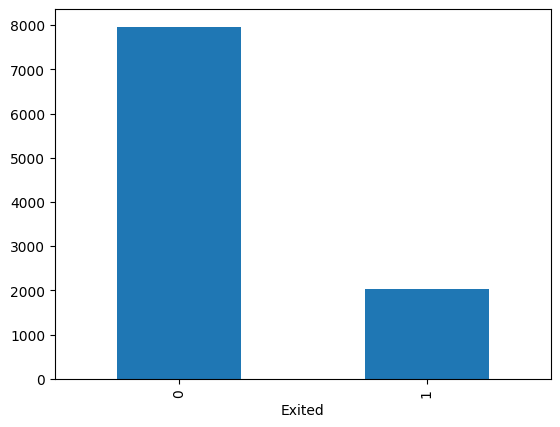

In [89]:
df['Exited'].value_counts().plot.bar();

In [90]:
import matplotlib.pyplot as plt

In [91]:
df.dtypes

CustomerId           int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
Tenure               int64
IsActiveMember       int64
Exited               int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
EstimatedSalary    float64
dtype: object

In [92]:
df.columns

Index(['CustomerId', 'Balance', 'NumOfProducts', 'HasCrCard', 'Tenure',
       'IsActiveMember', 'Exited', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'EstimatedSalary'],
      dtype='str')

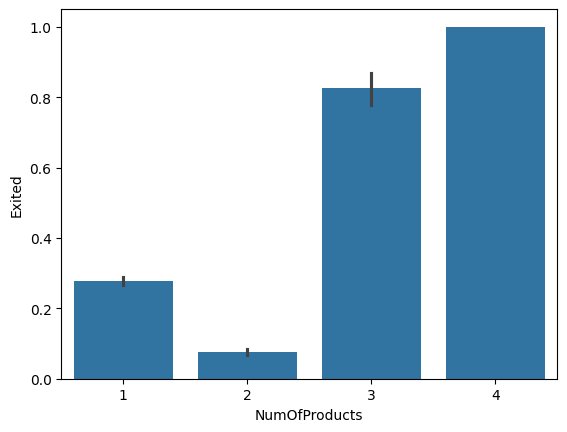

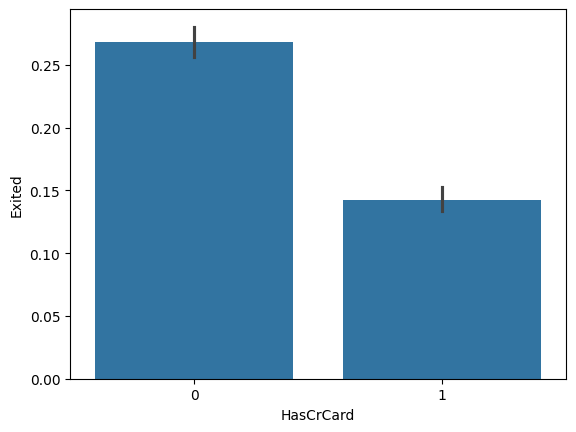

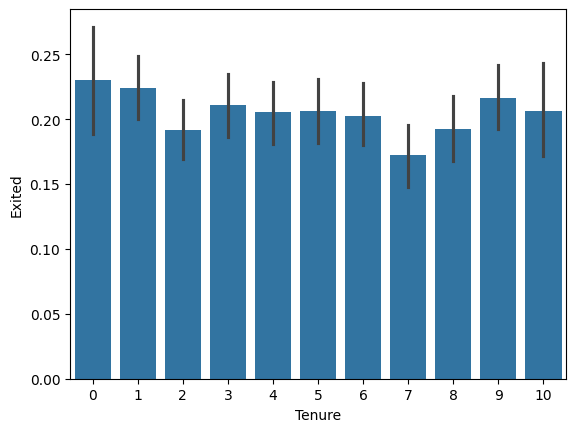

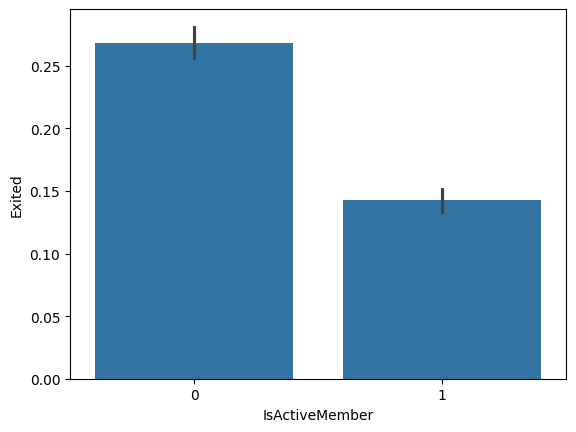

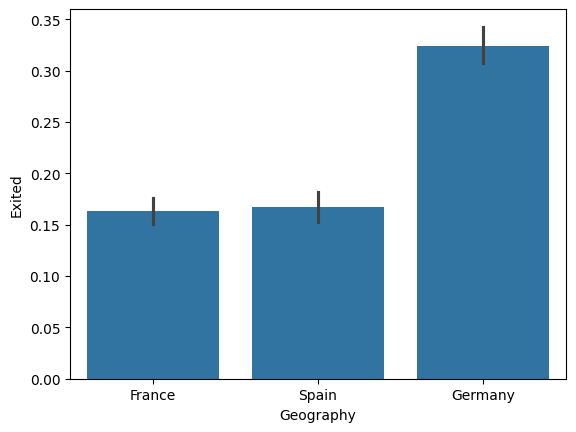

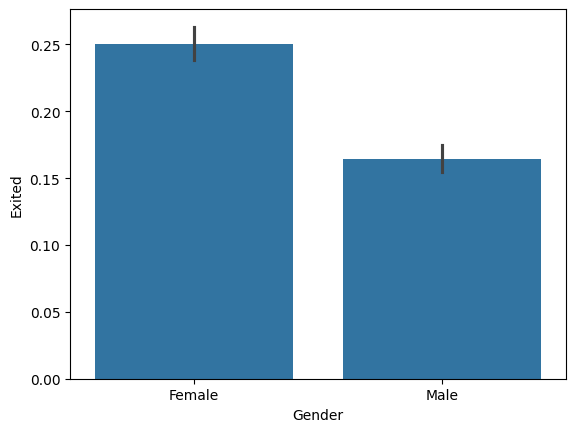

In [93]:
columns = ['NumOfProducts', 'HasCrCard', 'Tenure', 'IsActiveMember', 'Geography', 'Gender']
# for col in df.iloc[:,1:].select_dtypes(exclude=['str']):
for col in columns:
    if col != 'Exited':
        sns.barplot(data=df, x=col, y='Exited')
        plt.show()

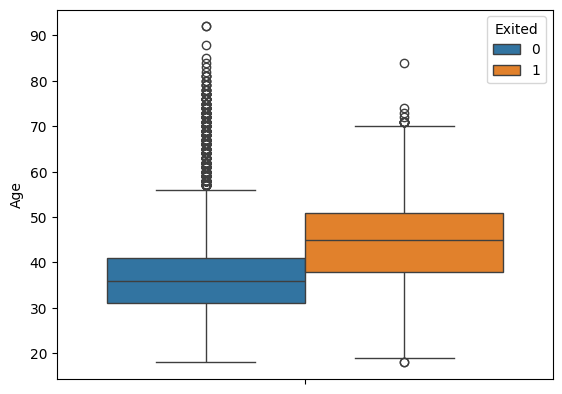

In [94]:
sns.boxplot(data=df, y='Age', hue='Exited');

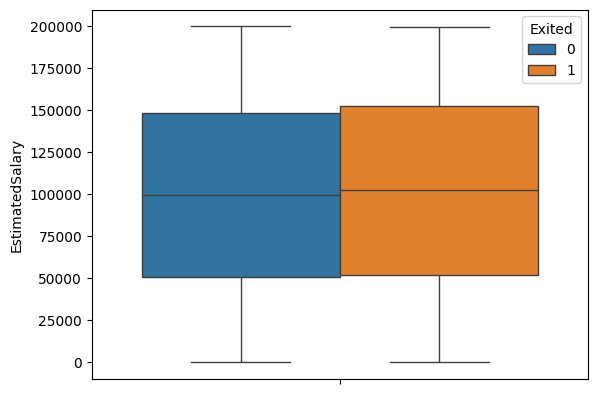

In [95]:
sns.boxplot(data=df, y='EstimatedSalary', hue='Exited');

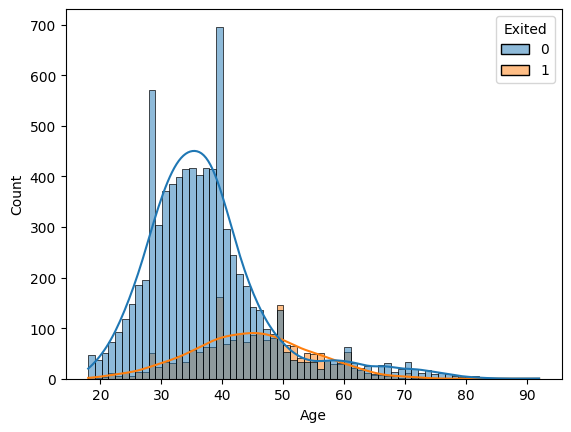

In [96]:
sns.histplot(data=df, x='Age', hue='Exited', kde=True);

In [97]:
df.columns

Index(['CustomerId', 'Balance', 'NumOfProducts', 'HasCrCard', 'Tenure',
       'IsActiveMember', 'Exited', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'EstimatedSalary'],
      dtype='str')

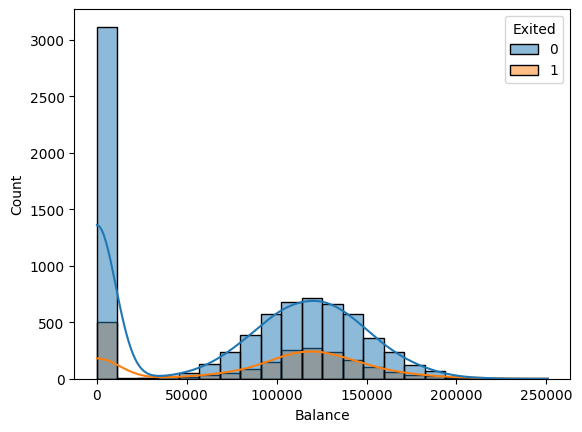

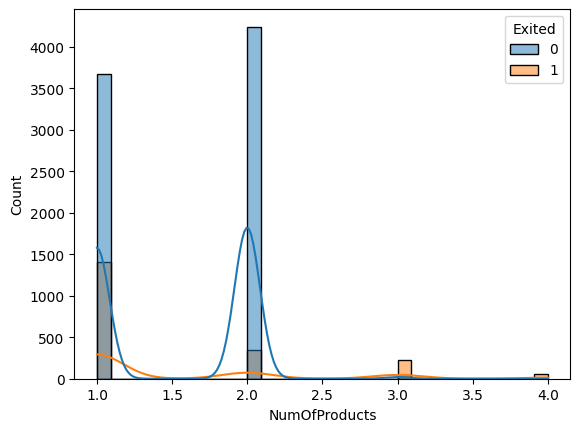

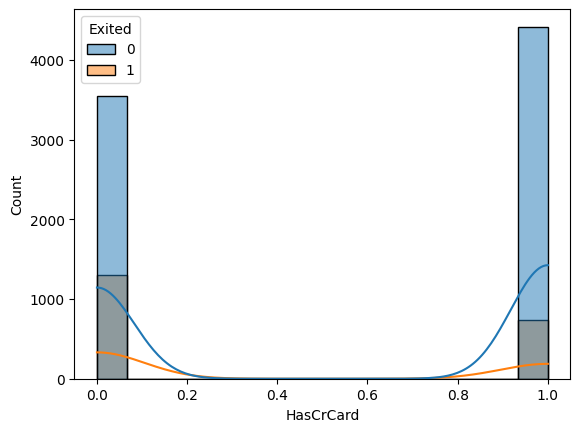

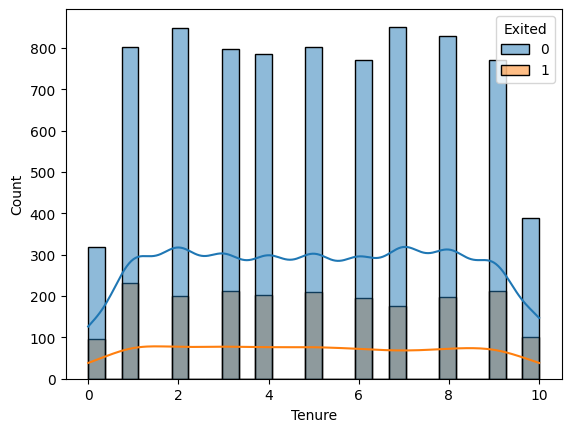

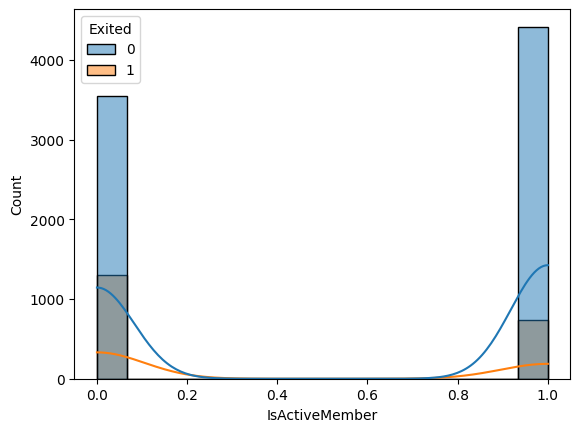

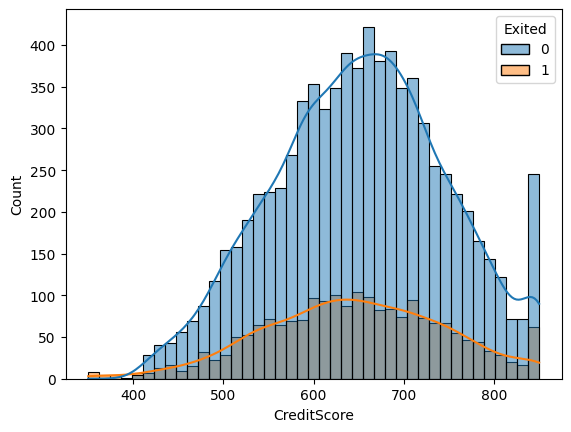

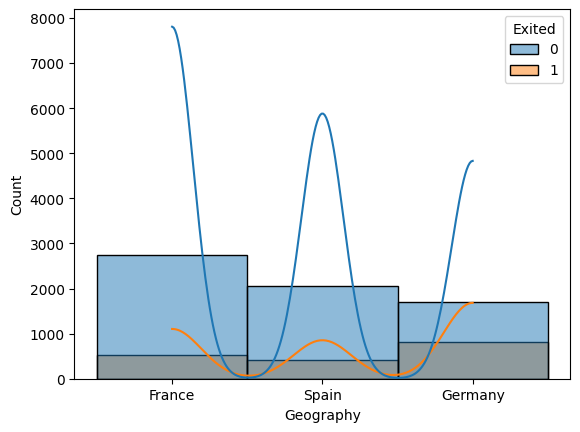

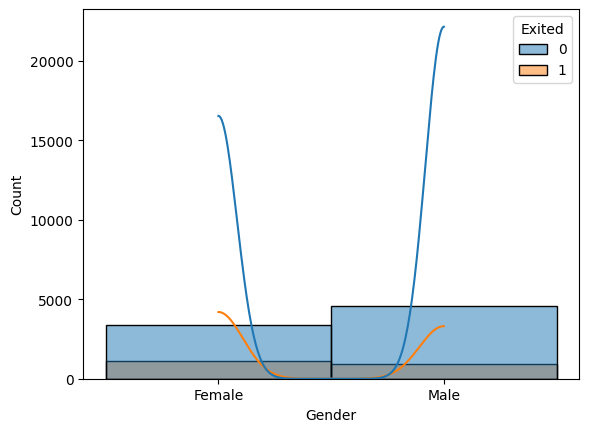

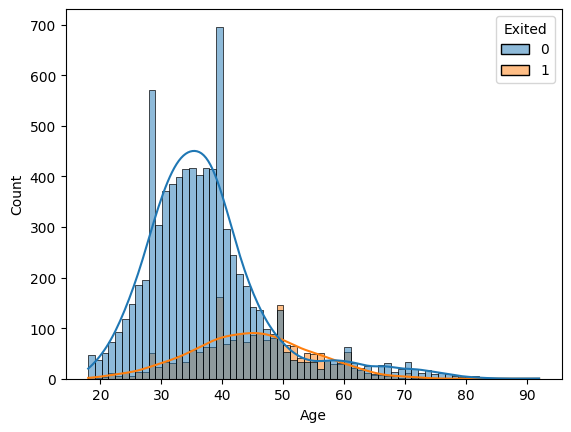

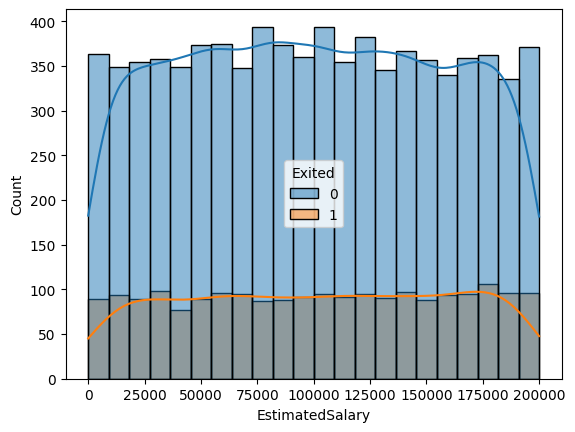

In [98]:
columns = ['Balance', 'NumOfProducts', 'HasCrCard', 'Tenure',
       'IsActiveMember', 'CreditScore', 'Geography',
       'Gender', 'Age', 'EstimatedSalary']
for col in columns:
    if col != 'Exited':
        sns.histplot(data=df, x=col, hue='Exited', kde=True)
        plt.show()

<h3>4. Prepare data for modeling</h3>

In [99]:
df.sample(10)

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,Surname,CreditScore,Geography,Gender,Age,EstimatedSalary
1690,15700854,0.00,1,0,8,0,1,Cunningham,595,Spain,Male,35,100015.79
9521,15673180,93816.70,2,0,2,0,0,Onyekaozulu,727,Germany,Female,18,126172.11
2554,15732270,0.00,1,1,8,1,1,Hung,727,Spain,Male,71,198446.91
1021,15654673,173434.90,1,0,6,0,1,Onyinyechukwuka,625,NaN,Male,49,165580.93
5333,15782641,119670.18,1,0,3,0,0,Brown,710,Spain,Female,29,188022.44
4262,15607278,134593.79,1,1,8,1,0,Romano,794,Spain,Female,46,46386.37
8958,15787825,152496.82,1,1,6,1,0,Okwudiliolisa,585,Germany,Male,37,99907.29
8634,15801414,0.00,2,0,2,0,0,Bitter,767,France,Female,35,144251.38
7686,15769980,92889.91,1,1,3,1,0,Singleton,705,Germany,Female,40,109496.69
5426,15595153,106022.73,2,0,8,0,0,Tucker,644,Germany,Female,44,148727.42


In [100]:
model = df.copy()

In [101]:
model.drop(columns=['Surname'], inplace=True)

In [102]:
geography = pd.get_dummies(model['Geography']).astype(int)
geography = geography.join(model['CustomerId'])
geography.head()

,France,Germany,Spain,CustomerId
0,1,0,0,15634602
2,0,0,1,15647311
3,1,0,0,15619304
4,1,0,0,15701354
5,0,0,1,15737888


In [103]:
model = model.merge(geography, on='CustomerId', how='left')
model.sample(10)

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,CreditScore,Geography,Gender,Age,EstimatedSalary,France,Germany,Spain
9451,15571586,159035.45,1,0,3,0,1,524,Spain,Male,29,2705.31,0,0,1
3798,15621834,0.00,2,0,0,0,0,700,Spain,Female,43,59475.35,0,0,1
408,15701376,152958.29,2,1,10,1,0,668,Germany,Male,37,159585.61,0,1,0
2574,15688691,110610.41,2,1,9,1,1,665,Germany,Female,51,1112.76,0,1,0
6862,15736287,0.00,1,0,9,0,0,586,NaN,Male,33,6975.02,0,0,0
7728,15637857,0.00,1,1,8,1,0,616,France,Female,31,76456.17,1,0,0
5987,15636634,79656.81,1,0,7,0,0,630,Germany,Female,25,93524.22,0,1,0
8626,15672447,99165.84,1,1,7,1,1,657,Germany,Male,40,119333.95,0,1,0
4030,15808760,0.00,1,1,6,1,0,603,Spain,Female,42,90437.87,0,0,1
7350,15713160,157228.61,2,0,7,0,0,669,Spain,Male,25,124382.90,0,0,1


In [104]:
gender = pd.get_dummies(model['Gender']).astype(int)
gender = gender.join(model['CustomerId'])
gender.head()

,Female,Male,CustomerId
0,1,0,15634602
1,1,0,15647311
2,1,0,15619304
3,1,0,15701354
4,1,0,15737888


In [105]:
model = model.merge(gender, on='CustomerId', how='left')
model.sample(10)

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,CreditScore,Geography,Gender,Age,EstimatedSalary,France,Germany,Spain,Female,Male
6621,15710365,104129.24,2,0,0,0,1,646,France,Male,50,181794.86,1,0,0,0,1
2517,15577064,104702.65,2,0,2,0,0,592,Germany,Male,36,107948.72,0,1,0,0,1
5410,15723613,0.00,2,0,4,0,0,623,NaN,Female,28,41227.67,0,0,0,1,0
2660,15756241,152509.25,1,1,2,1,0,767,France,Female,44,136915.15,1,0,0,1,0
2454,15636089,145751.03,1,0,1,0,1,678,Germany,Female,51,109718.44,0,1,0,1,0
9062,15753110,45752.78,2,0,3,0,1,720,Spain,Male,64,79623.28,0,0,1,0,1
3728,15806210,115654.47,2,1,5,1,0,675,Spain,Male,66,131970.86,0,0,1,0,1
7772,15614168,146710.76,1,0,4,0,1,792,Germany,Female,50,16528.40,0,1,0,1,0
3145,15775590,69329.47,1,0,2,0,1,482,Germany,Female,48,102640.52,0,1,0,1,0
1457,15590320,0.00,2,1,4,1,0,850,NaN,Male,66,64350.80,0,0,0,0,1


In [106]:
model.drop(columns=['Geography','Gender'],inplace=True)
model.sample(10)

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,CreditScore,Age,EstimatedSalary,France,Germany,Spain,Female,Male
1667,15718247,0.00,2,1,8,1,0,606,46,183717.94,0,0,1,1,0
2156,15762138,0.00,2,0,5,0,0,608,42,178504.29,0,0,0,0,1
5336,15700460,120905.03,1,1,4,1,1,530,55,123475.88,1,0,0,1,0
2531,15752300,148826.32,1,1,4,1,0,607,47,79450.61,0,1,0,0,1
1148,15616529,0.00,1,1,3,1,0,613,34,41724.72,0,0,1,0,1
3205,15733973,0.00,1,0,8,0,1,850,42,19632.64,0,0,0,1,0
7375,15638871,80926.02,2,1,6,1,0,639,77,55829.25,1,0,0,0,1
3809,15694805,115024.50,1,1,1,1,0,664,35,169665.79,0,0,1,0,1
4048,15653715,0.00,2,1,7,1,0,602,63,56323.21,1,0,0,1,0
9394,15615753,131101.04,1,1,8,1,0,597,35,192852.67,0,1,0,1,0


In [107]:
model[model.isna().any(axis=1)]

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,CreditScore,Age,EstimatedSalary,France,Germany,Spain,Female,Male


In [109]:
# balance vs income
model['balance_v_income'] = model['Balance']/model['EstimatedSalary']
model.sample(10)

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,CreditScore,Age,EstimatedSalary,France,Germany,Spain,Female,Male,balance_v_income
3219,15611191,122453.97,2,1,10,1,0,505,37,52693.99,0,1,0,1,0,2.323870
1021,15717164,102238.01,2,1,6,1,0,485,32,194010.12,0,0,1,0,1,0.526973
1496,15799156,0.00,2,0,8,0,0,569,38,79618.79,0,0,1,0,1,0.000000
6994,15589210,0.00,1,0,4,0,0,557,24,20515.72,1,0,0,1,0,0.000000
6242,15673333,96781.39,1,1,8,1,0,698,52,153373.71,0,1,0,0,1,0.631017
812,15578980,0.00,2,1,3,1,0,516,33,58685.59,0,0,1,1,0,0.000000
4328,15622527,0.00,1,1,6,1,0,581,55,22442.13,0,0,0,1,0,0.000000
9789,15814040,0.00,2,1,1,1,0,610,45,199657.46,0,0,0,1,0,0.000000
960,15686164,108822.40,1,1,1,1,0,850,31,132173.31,0,1,0,1,0,0.823331
2543,15655192,0.00,2,1,1,1,0,850,24,69052.87,0,0,1,1,0,0.000000


In [ ]:
model.groupby('Exited')['balance_v_income'].mean()

Exited
0    2.478339
1    9.352977
Name: balance_v_income, dtype: float64

Customers that resigned have greater balance/income ratio.